<a href="https://colab.research.google.com/github/jbgoncalvess/cifar100-cnn-model/blob/main/Tarefa_02_CNN_Cifar_100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático: Classificação de Imagens com Redes Neurais Convolucionais (CNNs)

**Informações da Tarefa:**
* **Tipo de Tarefa:** Trabalho Prático de CNNs para detecção de imagens
* **Disciplina:** IA na Borda
* **Professor:** Dr. Roderval Marcelino
* **Aluno:** Jardel Gonçalves

**Objetivo da Tarefa:**
O objetivo desta atividade é construir e treinar uma Rede Neural Convolucional (CNN) capaz de reconhecer e classificar imagens do dataset CIFAR-100. Básicamente tem 100 saídas possíveis, como homem, mulher, flor, golfinho ...

## Importando as libs necessárias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Dropout, BatchNormalization, RandomFlip, RandomTranslation, RandomRotation, RandomContrast, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import AdamW


# Métricas e gráficos para a matriz de confusão
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## Importar e inspecionar o Dataset

Repositório do CIFAR-100: https://www.cs.toronto.edu/~kriz/cifar.html





In [ ]:
# Carregando o dataset CIFAR-100
cifar100 = tf.keras.datasets.cifar100

# O label_mode='fine' carrega as 100 classes específicas.
# (Existe também o modo 'coarse' que agrupa em 20 superclasses) - não deu bom
(train_images, train_labels), (test_images, test_labels) = cifar100.load_data(label_mode='fine')

print("Formato dos dados de treino:", train_images.shape, train_labels.shape)
print("Formato dos dados de teste:", test_images.shape, test_labels.shape)

Formato dos dados de treino: (50000, 32, 32, 3) (50000, 1)
Formato dos dados de teste: (10000, 32, 32, 3) (10000, 1)


- O formato dos dados de imagem é: (#imagens, altura, largura, #canais), onde os canais estão no formato RGB.
- O formato dos rótulos (labels) é (#imagens, label), onde o label vai de 0 a 99. Tenho 100 possibilidades.


## Lista oficial das 100 classes e teste de imagem e seu label

Rótulo 19 - cattle


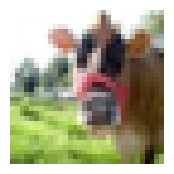

In [ ]:
# Lista oficial das 100 classes do CIFAR-100
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed',
    'bee', 'beetle','bicycle', 'bottle', 'bowl', 'boy', 'bridge',
    'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar',
    'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach',
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur','dolphin',
    'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard',
    'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle',
    'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
    'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain',
    'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray',
    'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk',
    'skyscraper','snail', 'snake', 'spider', 'squirrel', 'streetcar',
    'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone',
    'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
    'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# Função para mostrar a imagem e seu label, só pra ter ctz.
def plotar_imagem_treino(img_index, size=2):
    label = train_labels[img_index][0]
    plt.figure(figsize=(size, size))
    print(f"Rótulo {label} - {class_names[label]}")
    plt.imshow(train_images[img_index])
    plt.axis('off')
    plt.show()

# Testando a função com alguma imagem (index dela).
plotar_imagem_treino(0)

## Pré-processamento do Dataset

In [ ]:
# Normalizar os valores dos pixels para ficarem entre 0 e 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Separar uma parte dos dados de treino para validação
# 5k primeiras para validação
val_images = train_images[:5000]
val_labels = train_labels[:5000]

# Outras 45k depois da ultima de validação para treinamento
train_images = train_images[5000:]
train_labels = train_labels[5000:]

print("Treino (após separação):", train_images.shape, train_labels.shape)
print("Validação:", val_images.shape, val_labels.shape)

Treino (após separação): (45000, 32, 32, 3) (45000, 1)
Validação: (5000, 32, 32, 3) (5000, 1)


## Criar Arquitetura do Modelo e Compilar

- Aqui faremos uma alteração crucial: a última camada deve ter 100 neurônios para acomodar as 100 classes, obviamente.

In [ ]:
model = Sequential()


# 1 => DATA AUGMENTATION
model.add(RandomFlip("horizontal", input_shape=(32, 32, 3)))
model.add(RandomTranslation(height_factor=0.1, width_factor=0.1))
model.add(RandomRotation(factor=0.1))
model.add(RandomContrast(factor=0.2))
# ================================================================

# 2 => BLOCO CONVOLUCIONAL 1
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.1))
# ================================================================

# 3 => BLOCO CONVOLUCIONAL 2
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))
# ================================================================

# 4 => BLOCO CONVOLUCIONAL 3
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.3))
# ================================================================

# 5 => BLOCO CONVOLUCIONAL 4
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.4))
# ================================================================

# 6 => CLASSIFICAÇÃO FINAL
model.add(GlobalAveragePooling2D()) # Tirei o Flatten (- overfitting)
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(100, activation='softmax'))
# ================================================================

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 32, 32, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,851,108 (18.51 MB)

 Trainable params: 4,846,756 (18.49 MB)

 Non-trainable params: 4,352 (17.00 KB)

In [ ]:
# Compilar o modelo
# O AdamW ele permite o decaimento de peso de cada nó que começa a
# entrar em overfitting, assim não tem pixel viciado
model.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## Realizando o treinamento e plotando

- Tempo médio de treinamento está entre 55min e 1h.
- Normalmente está parando o treinamento antes por conta do early_stop.


In [ ]:
NUM_EPOCAS = 120
# Callbacks Inteligentes
# Reduz o Learning Rate se a rede empacar por 5 épocas seguidas
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                              min_lr=0.00001, verbose=1)

# Se o modelo não melhorar em 10 épocas, restaura os melhores pesos
early_stop = EarlyStopping(monitor='val_accuracy', patience=10,
                           restore_best_weights=True, verbose=1)

# Treinamento (Talvez o early_stop pare antes)
print("Iniciando treinamento...")
history = model.fit(train_images,
                    train_labels,
                    epochs=NUM_EPOCAS,
                    validation_data=(val_images, val_labels),
                    batch_size=128, # Processar 128 em 128
                    callbacks=[reduce_lr, early_stop])

Iniciando treinamento...
Epoch 1/120
352/352 ━━━━━━━━━━━━━━━━━━━━ 38s 72ms/step - accuracy: 0.0852 - loss: 4.1702 - val_accuracy: 0.0204 - val_loss: 5.3843 - learning_rate: 0.0010
Epoch 2/120
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.1709 - loss: 3.4805 - val_accuracy: 0.2256 - val_loss: 3.2136 - learning_rate: 0.0010
Epoch 3/120
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.2311 - loss: 3.1062 - val_accuracy: 0.2670 - val_loss: 3.0292 - learning_rate: 0.0010
Epoch 4/120
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.2862 - loss: 2.8204 - val_accuracy: 0.3218 - val_loss: 2.7004 - learning_rate: 0.0010
Epoch 5/120
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.3344 - loss: 2.5800 - val_accuracy: 0.3256 - val_loss: 2.8489 - learning_rate: 0.0010
Epoch 6/120
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.3679 - loss: 2.4267 - val_accuracy: 0.3656 - val_loss: 2.5561 - learning_rate: 0.0010
Epoch 7/120
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 

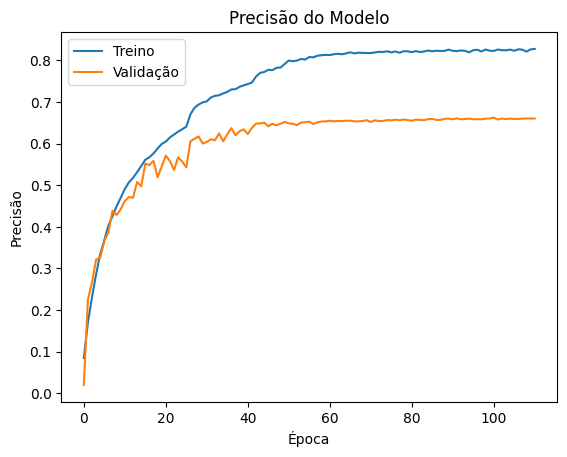

In [ ]:
# Resumo do histórico de precisão e acurácia
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Precisão do Modelo')
plt.ylabel('Precisão')
plt.xlabel('Época')
plt.legend(['Treino', 'Validação'], loc='upper left')
plt.show()

## Avaliação do Modelo

In [ ]:
print("Dados de Treino: ", model.evaluate(train_images, train_labels)[1])
print("Dados de Validação: ", model.evaluate(val_images, val_labels)[1])
print("Dados de Teste: ", model.evaluate(test_images, test_labels)[1])

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9177 - loss: 0.2622
Dados de Treino:  0.9176666736602783
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6622 - loss: 1.4132
Dados de Validação:  0.6621999740600586
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6656 - loss: 1.3785
Dados de Teste:  0.6656000018119812


- **NOTA**: Como o CIFAR-100 é muito mais complexo, a acurácia será naturalmente bem menor do que no CIFAR-10. Eu consegui entre *65%* e *67%*. Não consegui mais que isso professor, mesmo mudando os Hiperparâmetros várias vezes.

In [ ]:
# Fazendo predições
predictions = np.argmax(model.predict(test_images), axis=-1)

# Relatório de Classificação
print(classification_report(test_labels, predictions,
                            target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
               precision    recall  f1-score   support

        apple       0.87      0.82      0.85       100
aquarium_fish       0.88      0.74      0.80       100
         baby       0.61      0.65      0.63       100
         bear       0.69      0.44      0.54       100
       beaver       0.45      0.53      0.49       100
          bed       0.68      0.69      0.69       100
          bee       0.74      0.77      0.75       100
       beetle       0.61      0.74      0.67       100
      bicycle       0.63      0.91      0.74       100
       bottle       0.86      0.67      0.75       100
         bowl       0.44      0.39      0.41       100
          boy       0.48      0.41      0.44       100
       bridge       0.67      0.82      0.74       100
          bus       0.67      0.62      0.65       100
    butterfly       0.62      0.66      0.64       100
        camel       0.62      0.68      0.65       100
          can       0.6

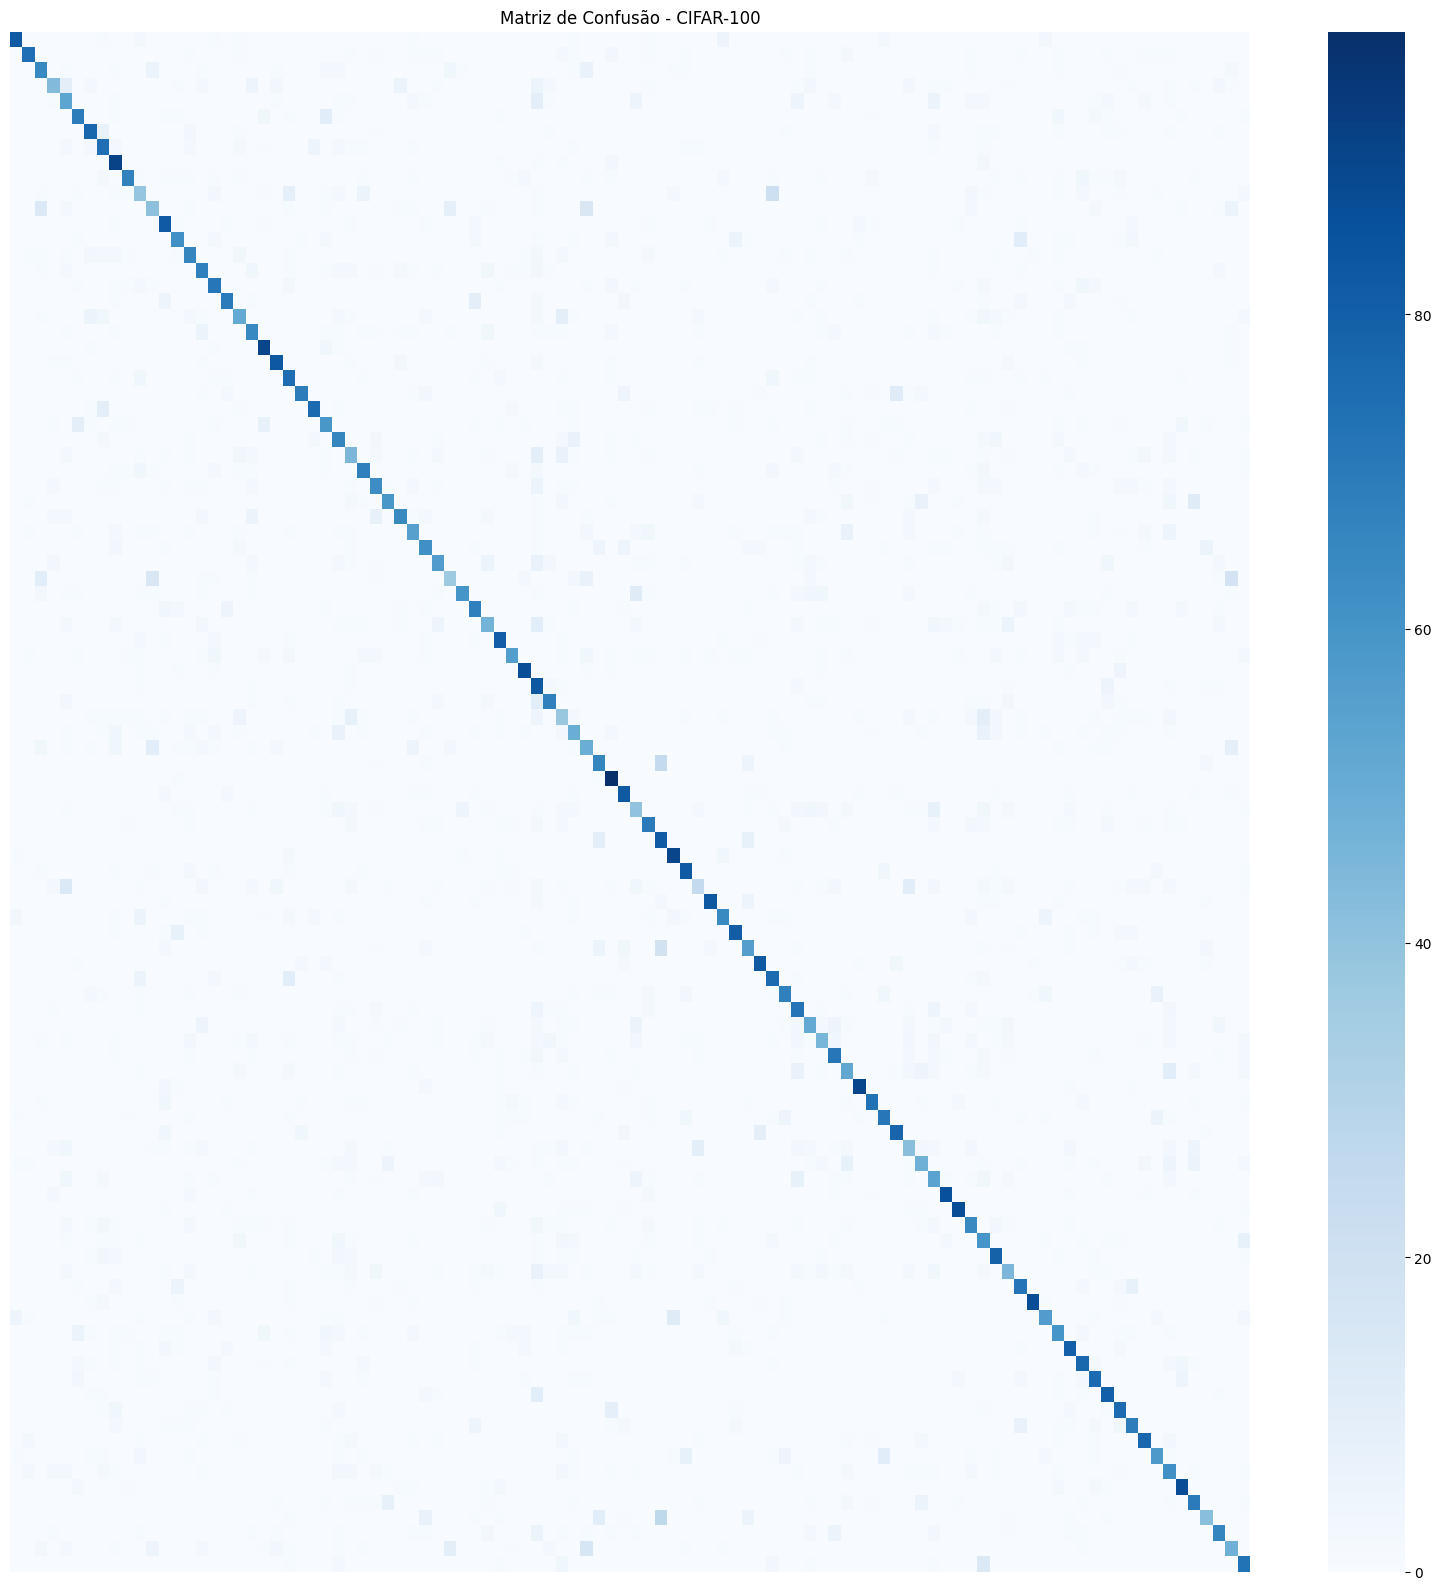

In [ ]:
# Matriz de Confusão
# Podemos plotar para ter uma ideia da diagonal principal.
plt.figure(figsize=(20,20))
sns.heatmap(confusion_matrix(test_labels, predictions),
            cmap='Blues', annot=False,
            xticklabels=False, yticklabels=False)
plt.title("Matriz de Confusão - CIFAR-100")
plt.show()

## Testando o Modelo (Predição Individual)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Rótulo Real: man => Predição do Modelo: man


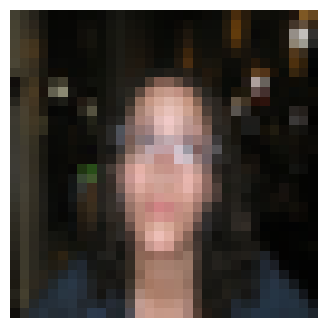

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Rótulo Real: bee => Predição do Modelo: bee


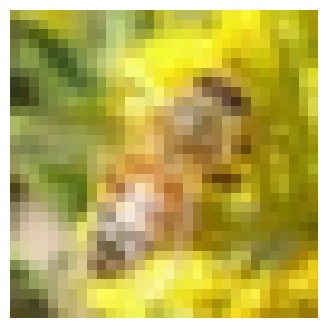

In [ ]:
def predizer_imagem(img_index, size=4):
    label_real = test_labels[img_index][0]
    minha_imagem = test_images[img_index]

    plt.figure(figsize=(size, size))
    plt.imshow(minha_imagem)

    minha_imagem_reshaped = minha_imagem.reshape(1, 32, 32, 3)

    img_pred = np.argmax(model.predict(minha_imagem_reshaped))
    pred_label = class_names[img_pred]
    nome_real = class_names[label_real]

    print(f"Rótulo Real: {nome_real} => Predição do Modelo: {pred_label}")
    plt.grid(False)
    plt.axis('off')
    plt.show()

# Testando algumas imagens do dataset de teste
predizer_imagem(129)
predizer_imagem(200)

## Salvando o modelo

In [ ]:
model.save('Tarefa_02_CNN_Cifar_100.keras')

## Considerações Finais

O CIFAR-100 impõe um grande desafio: classificar 100 categorias distintas contando com apenas 500 imagens de treinamento por classe. Essa escassez de dados, aliada à alta variabilidade visual, torna a rede extremamente suscetível ao overfitting.

Para solucionar esse problema e evoluir a arquitetura básica da CNN para um nível maior, foi implementado um conjunto robusto de técnicas avançadas de regularização, otimização e controle dinâmico de treinamento. Destacam-se as seguintes adições e seus respectivos impactos no modelo:

1. **Expansão Artificial dos Dados (Data Augmentation)**

     Para contornar a limitação de imagens e ensinar o modelo a focar nas características reais dos objetos (e não em suas posições ou iluminação), foi implementado um pipeline de Data Augmentation nativo. Com o uso das camadas abaixo, a rede foi forçada a reconhecer os objetos sob diversas perspectivas e condições:

    - RandomFlip: Inversão horizontal.

    - RandomTranslation: Deslocamentos laterais e verticais.

    - RandomRotation: Pequenas rotações.

    - RandomContrast: Alterações dinâmicas na iluminação.

    - Impacto: Essa estratégia aumentou drasticamente a capacidade de generalização do modelo para dados invisíveis.

---

2. **Evolução Arquitetural e Regularização**

    A estrutura interna da rede foi significativamente aprimorada em relação aos modelos base:

    - BatchNormalization: Esta camada foi inserida para normalizar as informações enquanto elas passam pela rede. Isso evita que os valores fiquem desregulados durante o treinamento, permitindo que o modelo aprenda mais rápido e com maior estabilidade.

    - Dropout: Técnica utilizada para evitar que a rede apenas decore as imagens. O método funciona "desligando" alguns neurônios aleatoriamente durante o treino, o que impede a dependência de caminhos únicos e obriga a rede a aprender padrões mais robustos.

    - GlobalAveragePooling2D (GAP): Em substituição à tradicional camada Flatten seguida de camadas Dense extensas, foi utilizado o GAP. Essa técnica reduz drasticamente o número total de parâmetros, tornando o modelo mais leve e diminuindo o risco de memorização dos dados (overfitting).

---

3. **Otimização Avançada e Estratégia de Lotes**

    - AdamW e batch_size: A transição para o otimizador AdamW foi fundamental, pois ele introduz o Weight Decay (decaimento de pesos), que penaliza pesos muito altos e evita a memorização excessiva. Além disso, o tamanho do lote (batch_size) foi ajustado para garantir o equilíbrio entre a estabilidade do treinamento e a introdução de uma variação saudável que auxilia o modelo a encontrar os melhores resultados.

---

4. **Controle Dinâmico do Treinamento (Callbacks)**

    O treinamento deixou de ser estático e passou a se adaptar ao desempenho da rede em tempo real através de callbacks:

    - ReduceLROnPlateau: Foi aplicado para monitorar a métrica de validação. Ao notar uma estagnação no aprendizado, a taxa de aprendizado (learning rate) é reduzida automaticamente, permitindo que o otimizador encontre ajustes mais precisos na reta final.

    - EarlyStopping: Atuou como a linha de defesa final. Ao perceber que o erro de validação começava a subir, o treinamento foi interrompido prematuramente, garantindo a preservação dos pesos do melhor estado histórico do modelo.

---

5. **Trabalhos Utilizados como Referência**

    Como base para a implementação das técnicas de Data Augmentation, Evolução Arquitetural, Otimização Avançada e Controle Dinâmico de Treinamento, foram consultados os artigos científicos listados a seguir. Estes trabalhos fornecem abordagens robustas para o treinamento de CNNs aplicadas especificamente ao dataset CIFAR-100 (às vezes comparando com o CIFAR-10 etc).

    A disponibilidade de representações visuais detalhadas das arquiteturas nestes estudos (frequentemente geradas por ferramentas como o Netron) foi fundamental para o processo de análise e replicação. Essas ilustrações facilitaram a compreensão da disposição das camadas e a integração de métodos de regularização, como o Dropout, permitindo uma adaptação precisa para o modelo desenvolvido neste projeto.

    ***Referências consultadas:***

    - [Wavelet‑Attention CNN for image classification](https://link.springer.com/article/10.1007/s00530-022-00889-8)
    - [B-CNN: Branch Convolutional Neural Network for Hierarchical Classification](https://arxiv.org/abs/1709.09890)
    - [Non-linear Convolution Filters for CNN-based Learning](https://openaccess.thecvf.com/content_iccv_2017/html/Zoumpourlis_Non-Linear_Convolution_Filters_ICCV_2017_paper.html)
    - [Tree-CNN: A hierarchical Deep Convolutional Neural Network for incremental learning](https://www.sciencedirect.com/science/article/pii/S0893608019302710?casa_token=GGyMLqKQyd4AAAAA:9_PONmd24SmwKVVjMuMZTvWafhKMQpSIG5TLczE124Ug-0PQBT07O8cip7eI7hHphvLAaj47fZSiNg)